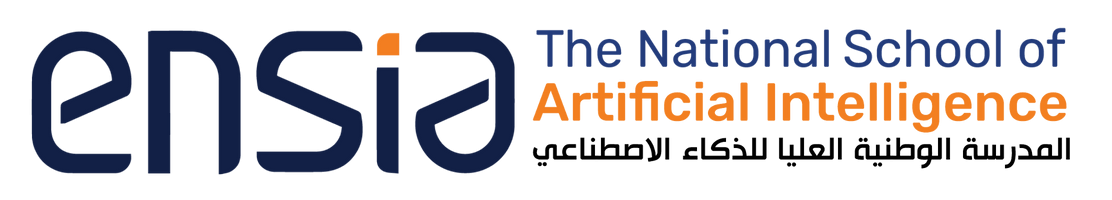

# **Overview**

> Support Vector Machines (SVMs) are error-based learning algorithms designed to find the optimal hyperplane that separates two classes by maximizing the margin on both sides of the decision boundary. Unlike linear or logistic regression, SVMs explicitly enforce a buffer (margin) around the classifier, leading to a quadratic-constrained optimization problem:
* **Primal formulation** directly optimizes the weight vector $w$ and bias $b$ under margin constraints.
* **Dual formulation** introduces Lagrange multipliers $\alpha_i$ to convert the problem into a quadratic program over {$\alpha_i$}, enabling kernelization and efficient solution via specialized QP solvers.





> This Lab constitutes the following three parts:
>
> ✅**Primal SVM with Gradient Descent** – Implement the primal SVM objective and train $w$ ,$b$ by (sub-)gradient descent, observing how the margin and hinge-loss interact.
>
> ✅**Dual SVM via Quadratic Programming** – Reformulate the SVM dual problem using Lagrange multipliers and solve it with a QP solver (CVXOPT), then recover $w$ and $b$ from the dual variables.
>
> ✅**Hyperparameter Sensitivity** – Use interactive sliders to explore how the choice of $C$ (soft vs. hard margin), kernel type (linear, polynomial, RBF), and kernel parameters affect decision boundaries, margins, and classification performance.

> Through hands-on implementation, you’ll gain deep insights into how these models operate, how we transition from the primal to the dual formulation, and how different kernel choices, regularization strengths, and other hyperparameters influence decision boundaries and overall performance

# **Introduction**

> Support Vector Machines (SVMs) seek to find the **maximum-margin hyperplane** that cleanly separates two classes of data. In a two-dimensional space, the decision boundary is given by:
$$
w^T ⋅ x - b = 0
$$

> For binary classification with labels $t ∈ \{-1, 1\}$, the classifier predicts according to the sign of  

$$
f(x) = w^T ⋅ x - b
$$

## **Training Objectives**

> To train an SVM, we must choose the weight vector **$w$** and bias **$b$** that:
1. **Maximize the margin between the two classes**, and
2. **Minimize misclassification errors** via the hinge loss.
### **Maximizing the Margin**
The margin is inversely proportional to the norm of the weight vector:
$$
Margin = (\frac{2}{||w||})
$$

Maximizing this margin is equivalent to minimizing the squared norm of the weights:

$$
\min_{w} (\frac{1}{2}||w||^2)
$$

### **Enforcing Correct Classification**
For a hard-margin SVM (no slack for misclassification), every training example ($x_i, y_i$) must satisfy:
$$
t_i ⋅ (w^T ⋅ x_i - b) ≥ 1
$$

This constraint ensures each point is not only classified correctly $t_i ⋅ f(x_i) > 0$ but also lies at least one margin-width away from the boundary.

## **Quadratic Constrained Optimization**
Because the objective involves the quadratic term $\frac{1}{2}||w||^2$ and the constraints are linear in **$w$** and **$b$**, training an SVM is a quadratic programming problem with linear constraints.

> The **primal** and **dual** formulations of Support Vector Machines (SVMs) are two different ways of expressing and solving the same optimization problem

* **Primal formulation**, optimizes directly over $w$ and $b$.
* **Dual formulation**, introduces **Lagrange multipliers $α_i$** and leverages the **kernel trick** for non-linear decision boundaries.

---
# **PART I: Primal Formulation**
---

Our custom SVM classifier minimizes a cost function with two components:

1. **Regularization term: $\frac{1}{2} ⋅ || w ||^2$** (To maximize the margin)
2. **Hing loss term: $ Loss_i = max(0,1 - t_i ⋅ (w^T ⋅ x_i - b))$** over all training examples.

Putting these together (using penalty C):

$$
J(w,b) = \frac{1}{2} ⋅ || w ||^2 + C \sum_{i=1}^{n} Loss_i
$$

Equivalently, one can absorb $C$ into a single regularization parameter $λ = \frac{1}{2C}$

$$
J(w,b) = λ ⋅ || w ||^2 + \sum_{i=1}^{n} Loss_i
$$

Where:
- λ: is a penalty term controlling the trade-off between margin size and misclassification

## Hing Loss Cases:
For a data point ($x_i, t_i$), let ($ z_i = t_i ⋅ (w^T ⋅ x_i - b)$).

1. Correctly classified and outside margin ($z_i ≥ 1$):
  * $Loss_i = 0  ⇒ $no penalty
2. Correctly classified but inside margin ($ 0 < z_i < 1$):
  * $Loss_i = 1 - z_i ⇒ $ small penalty
3. Misclassified (z_i ≤ 0):
  * $Loss > 1  ⇒ $ large penalty

## Gradients calculation

Because the hinge loss is piecewise, the gradients depend on whether $z_i ≥ 1$ or $z_i < 1$
1. If $z_i ≥ 1$ (no hinge penalty)
The cost reduces to the regularization term: $J(w, b) = \lambda ||w||^2$, thus
$$
\frac{σJ}{σw} = 2λ w, \hspace{2cm} \frac{σJ}{σb} = 0.
$$

2. If $z_i < 1$ (hinge loss active)
The loss includes both regularization and hinge terms:$J(w, b) = \lambda ||w||^2 + 1- z_i$, thus (taking derivatives):

$$
\frac{σJ}{σw} = 2λ w - t_i x_i, \hspace{2cm} \frac{σJ}{σb} = - t_i.
$$

## Parameters updates (Gradient descent):
Using the calculated gradients, we can proceed with gradient descent updates as follows:

$$
w = w - ƞ ⋅ [2λ w - \sum_{i: z_i < 1} t_i x_i], \hspace{2cm} b = b - ƞ ⋅ [- \sum_{i: z_i < 1} t_i].
$$

Where:
* $ƞ$ is the learning rate.

## **Implementation**

In [14]:
!pip install cvxopt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from cvxopt import matrix, solvers


## **Utility Functions**

In [15]:
def load_linear_data():
  X, y = make_blobs(n_samples=100, centers=2, cluster_std=1.5, random_state=6)
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 5)
  return X_train, X_test, y_train, y_test

def load_non_linear_data(N, D=2, K=2):
    X = np.zeros((N * K, D))  # data matrix (each row = single example)
    y = np.zeros(N * K)  # class labels

    for j in range(K):
        ix = range(N * j, N * (j + 1))
        r = np.linspace(0.0, 1, N)  # radius
        t = np.linspace(j * 4, (j + 1) * 4, N) + np.random.randn(N) * 0.2  # theta
        X[ix] = np.c_[r * np.sin(t), r * np.cos(t)]
        y[ix] = j

    # lets visualize the data:
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
    plt.show()

    y[y == 0] -= 1

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 5)
    return X_train, X_test, y_train, y_test

In [16]:
from matplotlib.colors import ListedColormap
def plotdata(X,y):
        pos = y == 1
        neg = y == -1
        plt.plot(X[pos, 0], X[pos, 1], 'o', ms=5)
        plt.plot(X[neg, 0], X[neg, 1], 'o', ms=5)

def visualizeBoundary(X, y, model, title='SVM Decision Boundary'):
    # ensure y is ±1
    y_signed = np.where(y<=0, -1, +1)
    X = standardize(X)
    # plot raw data
    plt.scatter(X[y_signed==+1,0], X[y_signed==+1,1],
                c='C0', marker='o', edgecolors='k', label='+1')
    plt.scatter(X[y_signed==-1,0], X[y_signed==-1,1],
                c='C1', marker='s', edgecolors='k', label='-1')

    # build a grid
    x1 = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200)
    x2 = np.linspace(X[:,1].min()-1, X[:,1].max()+1, 200)
    X1, X2 = np.meshgrid(x1, x2)
    pts = np.c_[X1.ravel(), X2.ravel()]

    # get the raw decision scores f(x) = w·x + b  (shape (200*200,))
    # if you have a .decision_function, use that; otherwise use .forward
    Z = model.forward(pts).reshape(X1.shape)

    # fill the two half‑spaces with different colors
    cmap = ListedColormap(['#FFCCCC', '#CCCCFF'])  # light red / light blue
    plt.contourf(
        X1, X2, Z > 0,        # boolean mask: True/False → two regions
        levels=[-0.5, 0.5, 1.5],
        cmap=cmap,
        alpha=0.4
    )
    # contour at f=0 for boundary, at f=±1 for margins
    plt.contour(X1, X2, Z,
                levels=[-1, 0, +1],
                colors=['gray','k','gray'],
                linestyles=['--','-','--'],
                linewidths=[1,2,1])

    plt.pcolormesh(X1, X2, Z, cmap='YlGnBu', alpha=0.25, edgecolors='None', lw=0)

    # highlight support vectors
    f_vals = model.forward(X)
    # Since we already stored support vectors indices when fitting,
      # then use them directly
    # sv = getattr(model, "sv", None)
    # if sv is not None:
    #   plt.scatter(X[sv,0], X[sv,1],
    #               s=150, facecolors='none', edgecolors='g',
    #               linewidths=2, label='Support Vectors')
    # else:
    # In case you did not store sv indices use this condition to get them.
    sv = np.abs(y_signed * f_vals - 1) < 1e-6
    plt.scatter(X[sv,0], X[sv,1],
                s=150, facecolors='none', edgecolors='g',
                linewidths=2, label='Support Vectors')

    plt.legend()
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

In [17]:
def standardize(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    # Replace zeros in std with 1 to avoid division by zero
    std[std == 0] = 1e-6
    return (X - mean) / std

## Primal SVM Classifier

In [18]:
class Primal_SVM:
    """
    A Support Vector Machine (SVM) implementation using gradient descent.

    predict(X)
        Predicts the labels (the sign of decision values) for the given data.
    forward(X):
        Compute the decision function f(x) = w^T x + b.
    """

    def __init__(self, iterations=1000, lr=0.01, lambdaa=0.01):
        self.lambdaa = lambdaa# TODO: Set lambda (regularization strength) controlling margin vs. misclassification trade-off
        self.iterations = iterations# TODO: Set number of iterations for gradient descent
        self.lr = lr# TODO: Set learning rate
        self.w = None# TODO: Initialize weights
        self.b = None# TODO: Initialize bias
        self.fitted = False# TODO: Boolean Flag to check if model has been fitted

    def initialize_parameters(self, X):
        """
        Initializes the weights and bias.
        """
        m, n = X.shape# TODO: Get number of features from input data X
        self.w = np.zeros(n)# TODO: Initialize weights to zeros
        self.b = 0# TODO: Initialize bias to 0

    def gradient_descent(self, X, y):
        """
        Updates the weights and bias using gradient descent.
        """
        y_ = 2 * y - 1  # TODO: Convert labels to {-1, 1} for hinge loss computation
        for i, x in enumerate(X):
            # Compute the gradients (backward method in linear regression)

            z_i = y_[i] * (np.dot(self.w, x) - self.b)  # TODO: Calculate margin value z_i = y_i * (w·x_i - b) using forward(X) function
            # This is the functional margin for the current point
            # If z_i ≥ 1, the point is correctly classified outside the margin
            # If 0 < z_i < 1, the point is correctly classified but inside the margin
            # If z_i ≤ 0, the point is misclassified

            if z_i >= 1: # TODO: If no hinge penalty (𝑧𝑖≥1)
                # TODO: Compute gradient when correctly classified
                dw = self.lambdaa * self.w  # Regularization gradient
                db = 0  # No bias update when correctly classified
            else:
                # TODO: Compute gradient when misclassified
                dw = self.lambdaa * self.w - y_[i] * x  # Regularization + hinge loss gradient
                db = -y_[i]  # Bias gradient from hinge loss
            #Update the parameters
            self.update_parameters(dw, db)

    def update_parameters(self, dw, db):
        """
        Updates the weights and bias.
        """
        self.w = self.w - self.lr * dw  # TODO: Update weights using gradient descent rule
        self.b = self.b - self.lr * db  # TODO: Update bias using gradient descent rule

    def fit(self, X, y):
        """
        Fits the SVM to the data.
        """
        mean = np.mean(X, axis=0)
        std = np.std(X, axis=0)
        std[std == 0] = 1
        X = (X - mean) / std
        self.mean = mean
        self.std = std
        self.initialize_parameters(X)  # TODO: Initialize model parameters (w, b)
        for i in range(self.iterations):  # TODO: Loop through specified number of iterations
            self.gradient_descent(X, y)  # TODO: Perform one step of gradient descent

        self.fitted = True  # TODO: Set fitted flag to True after training

        return self

    def forward(self, X):
        """
        Compute the decision function f(x) = w^T x + b.
        """
        output = X @ self.w + self.b  # TODO: Calculate the decision function f(x) = w·x - b
        return output

    def predict(self, X):
        """
        Predicts the class labels for the test data.
        """
        X = (X - self.mean) / self.std  # TODO: Standardize input features
        output = self.forward(X)  # TODO: Get raw decision values from forward pass

        # get the signs of the labels depending on if it's greater/less than zero
        label_signs = np.sign(output)  # TODO: Convert to -1/+1 based on sign of decision values

        #set predictions to 0 if they are less than or equal to -1 (label_signs<= -1) else set them to 1
        predictions = (label_signs + 1) // 2  # TODO: Convert to 0/1 class labels
        return predictions # The predicted class labels.

    def score(self, X, y):
        from sklearn.metrics import accuracy_score
        y_pred = self.predict(X)  # TODO: Get model predictions
        return accuracy_score(y, y_pred)  # TODO: Calculate and return accuracy

## Testing Our Primal model

**Note**: Keep tweeking the lambda and lr parameters and see their impact

0.5333333333333333


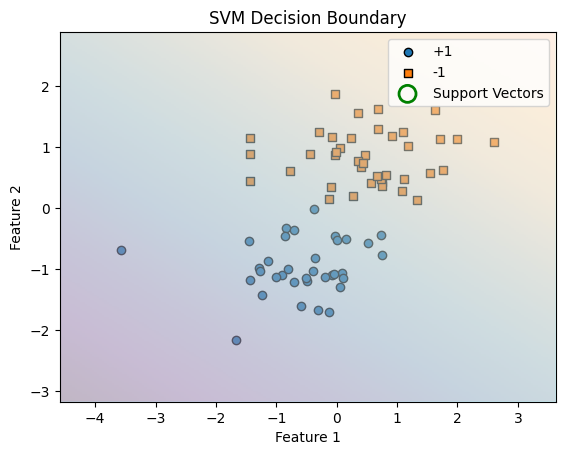

In [19]:
X_train, X_test, y_train, y_test = load_linear_data()
model = Primal_SVM(lambdaa=0.01, lr=0.01, iterations=1000)  # TODO: Experiment with different values of lambda and learning rate
model.fit(X_train, y_train)
predictions = model.predict(X_train)

print(model.score(X_train, y_train))
visualizeBoundary(X_train, y_train, model)

### Try with non linear data

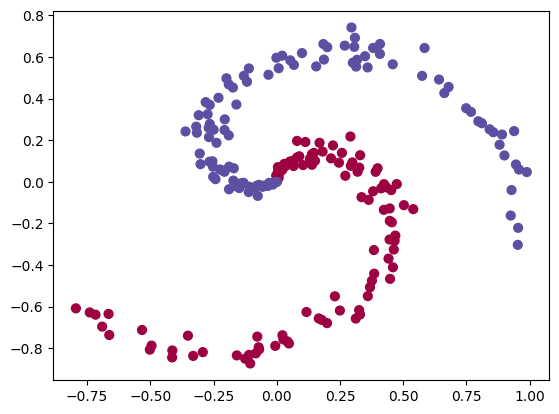

0.0


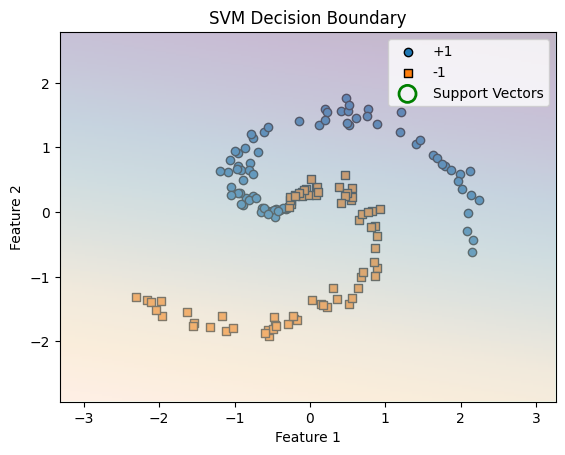

In [20]:
X_train_non, x_test_non, y_train_non, y_test_non = load_non_linear_data(N=100)
model_non = Primal_SVM(lambdaa=0.01, lr=0.01, iterations=1000) #TODO: initialze a Primal SVM object
model_non.fit(X_train_non, y_train_non)
predictions = model_non.predict(X_train_non)

print(model_non.score(X_train_non, y_train_non))

visualizeBoundary(X_train_non, y_train_non, model_non)

---
# **PART II: Dual Formulation**
---

$$\require{cancel}$$
In the primal formulation we optimized directly over $w$ and $b$. The dual formulation recasts the same problem in terms of Lagrange multipliers $\alpha_i$. This lets us:
* Leverage the kernel trick for non-linear boundaries, and
* Work efficiently with QP solvers when the number of samples is moderate.

## **From Primal to Dual Optimization formulation**
> Lagrange method is required to convert constrained optimization problem into unconstrained optimization problem, so using lagrange multipliers $\alpha_i$ we can write:

$$
l = \frac{||w||^2}{2} - \sum_{i=1}^{m} \alpha_i(t_i(w ⋅ x_i + b) - 1)
$$

$$
l = \frac{||w||^2}{2} - \sum_{i=1}^{m} \alpha_i(t_i(w ⋅ x_i + b)) + \sum_{i=1}^{m} \alpha_i
$$

$$
l = \frac{||w||^2}{2} - \sum_{i=1}^{m} \alpha_i ⋅ t_i ⋅ w ⋅ x_i - \sum_{i=1}^{m} \alpha_i ⋅ t_i ⋅ b + \sum_{i=1}^{m} \alpha_i
$$

> To find the optimal solution, we compute the gradients of the Lagrangian with respect to $w$, $b$, and $\alpha_i$. At the optimum, all these gradients must be zero (stationarity conditions):

$$
\frac{σJ}{σw} = w - \sum_{i=1}^{m} \alpha_i ⋅ t_i ⋅ x_i = 0
$$
$$
\frac{σJ}{σ𝛼} = \sum_{i=1}^{m} t_i(w ⋅ x_i + b) - 1 = 0
$$
$$
\frac{σJ}{σb} = \sum_{i=1}^{m} \alpha_i ⋅ t_i = 0
$$

> Meaning that:

$$
\sum_{i=1}^{m} \alpha_i ⋅ t_i = 0
$$
$$
w = \sum_{i=1}^{m} \alpha_i ⋅ t_i ⋅ x_i
$$

> Now we can substitute in the primal equation above:

1. **Regularization term**:
$$
\frac{1}{2}(\sum_{i=1}^{m} \alpha_i ⋅ t_i ⋅ x_i)^T (\sum_{i=1}^{m} \alpha_i ⋅ t_i ⋅ x_i) = \frac{1}{2} \sum_{i=1}^{m}\sum_{j=1}^{m} \\alpha_i ⋅ \alpha_j ⋅  t_i ⋅ t_j ⋅ x_i ⋅ x_j
$$

2. **Term 2**:
$$
- \sum_{i=1}^{m} \alpha_i ⋅ t_i ⋅ w ⋅ x_i = - \sum_{i=1}^{m}\sum_{j=1}^{m} \alpha_i ⋅ \\alpha_j ⋅  t_i ⋅ t_j ⋅ x_i ⋅ x_j
$$
3. **Term 3**:
This term vanishes.
$$
\sum_{i=1}^{m} \alpha_i ⋅ t_i = 0 \Rightarrow \cancel{\sum_{i=1}^{m} \alpha_i ⋅ t_i ⋅ b} = 0
$$
4. **Term 4**: Stays unchanged.
$$
+ \sum_{i=1}^{m} \alpha_i
$$

> The final Dual Formulation becomes:

$$
l = \frac{1}{2} \sum_{i=1}^{m}\sum_{j=1}^{m} \alpha_i ⋅ \alpha_j ⋅  t_i ⋅ t_j ⋅ x_i ⋅ x_j - \sum_{i=1}^{m}\sum_{j=1}^{m} \alpha_i ⋅ \alpha_j ⋅  t_i ⋅ t_j ⋅ x_i ⋅ x_j + \sum_{i=1}^{m} \alpha_i
$$

> Thus, The objective of this dual formulation is to maximize $l$:

$$ \pmb{l = \sum_{i=1}^{m} \alpha_i - \frac{1}{2} \sum_{i=1}^{m}\sum_{j=1}^{m} \alpha_i ⋅ \alpha_j ⋅  t_i ⋅ t_j ⋅ K(x_i, x_j)}
$$

> subject to the linear constraints:

$$
\pmb{\sum_{i=1}^{m} \alpha_i ⋅ t_i = 0, \quad 0 \leq \alpha_i \leq C}
$$

> Where:
- $\alpha_i$ are Lagrange multipliers,
- $K(x_i, x_j)$ is the kernel function (for a linear SVM, $K(x_i, x_j) = x_i^T x_j$),
- $C$ is the penalty parameter in soft-margin SVM.

### Decision function
> Once the $\alpha_i$ are found, the weight vector $w$ in the original space is (**`compute_weights`**):

$$
w = \sum_{i=1}^{m} \alpha_i ⋅ t_i ⋅ x_i
$$

> For any support vector $x_k$ with $0 < \alpha_k < C$:

$$
b = t_k - \sum_{i=1}^n \alpha_i ⋅ t_i \cdot K(x_i, x_k)
$$

> Or, averaged over all support vectors $S$ (This is the formula numerical stability **`compute_bias method`** ):

$$
b = \frac{1}{\lvert S\rvert} \sum_{k \in S}[ t_k - \sum_{i=1}^n \alpha_i ⋅ t_i K(x_i, x_k)]
$$

> A new point $x$ is classified via (**`predict method`**):

$$
f(x) = \sum_{i=1}^{m} \alpha_i ⋅ t_i K(x_i, x) + b ⇒ \hat{t}= sign(f(x))
$$

> Only points with $\alpha_i > 0$ (support vectors) contribute to the sum.

### Kernal Functions

> To solve the soft margin problem we apply the **kernel trick**. You just need to create a kernel matrix and replace the values of $x$ with this matrix i.e you transformed your data to a new, more expressive feature space without actually transforming the data. Types of **Kernels**:  

> - Linear Kernel
$$
K = x_i^T \cdot x_j
$$
- Polynomial Kernel
$$
K = (x_i^T \cdot x_j + c)^d
$$
- Gaussian kernel (or Radial Basis Function)
$$
K = e^{(-\frac{||x_i - x_j||^2}{2σ^2})}
$$

> Where:
- $c$ is a constant(typically $≥$ 0)
- $d$ is the degree of the polynomial
- $σ$ is the kernal coefficient that controls the width of the Gaussion (related to how far the influence of a single training example reaches).

###***Quadratic Programming using CVXOPT***

> The general form of a ***quadratic programming (QP)*** problem is to minimize an objective function subject to certain constraints.

> The objective function is quadratic, and the constraints are linear. The QP problem is expressed as:

>***1 - Objective Function***: minimize $(1/2) \cdot x^T . Px + q^T . x$

>- ***( x )*** is the vector of variables we want to solve for,
- **( P )** is a symmetric matrix that defines the quadratic part of the objective function. For SVM, it’s derived from the outer product of the target vector y and the kernel matrix of the data points.
- **( q )** is a vector that defines the linear part of the objective function. In the case of SVM, it’s typically a vector of -1’s.


> ***2- Constraints:***
>- **Inequality Constraints:** ( $Gx \leq h $)
- __ ***( G )*** is a matrix and ***( h )*** is a vector often a vector of zeros. These define the linear inequality constraints that the solution ( x ) must satisfy.
- **Equality Constraints:** $( Ax = b )$
- __***( A )*** is matrix for equality constraints, which represents the condition that the sum of the product of the labels and the Lagrange multipliers is zero. ***( b )*** is a vector, which is just zero in the case of SVM. These define the linear equality constraints that the solution ( x ) must satisfy.

> In the context of SVM, the ***QP problem*** is used to find the ***optimal weights*** and ***bias*** that define the **hyperplane** separating the data points in feature space with the **maximum margin**.

> **CVXOPT** is an optimization library in python. You can use **qp solver** of **CVXOPT** to solve quadratic problems like the SVM optimization problem. You  just need to convert your SVM problem into the QP format, where :
- create matrices P, q, A, G, h and
- initialize a value for b.
$$
P = \text{Kernel matrix (Gram matrix)} \quad \text{(with label adjustments)}
$$
$$
q = -\mathbf{1}, \quad G = \begin{bmatrix} -I \\ I \end{bmatrix}, \quad h = \begin{bmatrix} 0 \\ C \end{bmatrix}, \quad A = y^T, \quad b = 0
$$

> The solver then will return the lagrange multipliers $α$
$$
\alpha = \text{solver}(P, q, G, h, A, b)
$$

## Main CVXOPT_SVM Class

In [21]:
class CVXOPT_SVM():
    def __init__(self, kernel="linear", C=1, sigma=None, degree= None):
        """
        Initialize the SVM with specified kernel and parameters.

        Args:
            kernel: Kernel type ('linear', 'polynomial', or 'rbf')
            C: Regularization parameter for soft margin SVM
            sigma: Width parameter for Gaussian kernel
            degree: Degree parameter for polynomial kernel
        """
        match kernel:  # Use match-case statement to select the appropriate kernel function based on input
          case "linear":
            self.kernel = self.linear_kernel # TODO: Set kernel to linear kernel function if "linear" is specified
          case "polynomial":
            self.kernel = self.polynomial_kernel # TODO: Set kernel to polynomial kernel function if "polynomial" is specified
          case "rbf":
            self.kernel = self.gaussian_kernel # TODO: Set kernel to Gaussian kernel function if "rbf" is specified
          case _:
            self.kernel = self.linear_kernel # TODO: Default to linear kernel if an invalid kernel is specified

        self.C = C # TODO: Store the regularization parameter C
        self.sigma = sigma # TODO: Store the sigma parameter for Gaussian kernel
        self.degree = degree # TODO: Store the degree parameter for polynomial kernel
        self.fitted = False # TODO: Initialize fitted flag to False (model hasn't been trained yet)

    def linear_kernel(self, x, z):
        """
        Compute linear kernel: K(x,z) = x·z

        Args:
            x: First data point or array
            z: Second data point or array

        Returns:
            Dot product between x and z
        """
        return np.dot(x, z) # TODO: Calculate linear kernel: 𝐾=x⋅z^𝑇

    def polynomial_kernel(self, x, z, d=5):
        """
        Compute polynomial kernel: K(x,z) = (1 + x·z)^d

        Args:
            x: First data point or array
            z: Second data point or array
            d: Polynomial degree (default=5)

        Returns:
            Polynomial kernel value
        """
        if self.degree:
          d = self.degree
        return (1 + np.dot(x, z)) ** d # TODO: Calculate polynomial kernel: (1 + dot product between x and transpose z)^degree

    def gaussian_kernel(self, x, z, sigma=0.13):
        """
        Compute Gaussian/RBF kernel: K(x,z) = exp(-||x-z||²/(2σ²))

        Args:
            x: First data point or array
            z: Second data point or array
            sigma: Kernel width parameter (default=0.13)

        Returns:
            Gaussian kernel value
        """
        if self.sigma:
          sigma = self.sigma
        return np.exp(-np.linalg.norm(x - z)**2 / (2 * sigma**2)) # TODO: Calculate Gaussian kernel value: exp(-||x-z||²/(2σ²))

    def setup_quadratic_problem(self, m):
        """
        Set up the matrices for the quadratic programming solver.

        Args:
            X (numpy array): Feature matrix.
            y (numpy array): Label vector.
            C (float): Penalty parameter for soft margin SVM.

        Returns:
            P, q, G, h, A, b: Matrices for the cvxopt solver.
        """
        y = self.y                                                  # Get the labels vector

        P = matrix(np.outer(self.y, self.y) * self.K)               # Create P matrix for quadratic term. it’s derived from the outer product of the target vector y and the kernel matrix of the data points.
        q = matrix(-np.ones((m, 1)))                                # Create q vector for linear term: all -1's (since we're maximizing)
        G = matrix(np.vstack((np.eye(m) * -1, np.eye(m))))          # Create G matrix for inequality constraints: [-I; I] to enforce 0 ≤ α ≤ C
        h = matrix(np.hstack((np.zeros(m), np.ones(m) * self.C)))   # Create h vector for inequality constraints: [0; C] to enforce 0 ≤ α ≤ C
        A = matrix(self.y, (1, m), "d")                             # Create A matrix for equality constraint: y^T to enforce Σ(α_i*y_i) = 0
        b = matrix(np.zeros(1))                                     # Create b vector for equality constraint: Set to zero
        return P, q, G, h, A, b

    def solve(self, P, q, G, h, A, b):
        """
        Solve the quadratic programming problem using CVXOPT.

        Args:
            P, q, G, h, A, b: Matrices for the QP solver

        Effects:
            Sets self.alphas with the optimal Lagrange multipliers
        """
        solvers.options["show_progress"] = False
        sol = solvers.qp(P, q, G, h, A, b) # TODO: Solve the quadratic programming problem using CVXOPT's qp solver
        self.alphas = np.ravel(sol["x"])   # Extract and flatten the solution (α values) from the solver result

    def fit(self, X, y):
        """
        Fit the SVM model to training data.

        Args:
            X: Feature matrix of shape (n_samples, n_features)
            y: Target vector of shape (n_samples,)

        Returns:
            Self (for method chaining)
        """
        self.y = np.where(y == 0, -1, 1) # TODO: Convert labels to -1/+1 format required by SVM formulation (use np.where())
        mean = np.mean(X, axis=0)
        std = np.std(X, axis=0)
        std[std == 0] = 1
        X = (X - mean) / std
        self.X = X                      # TODO: Store the standardized feature matrix
        self.mean = mean
        self.std = std
        m, n = X.shape                        # TODO: Get the dimensions of the feature matrix


        # Calculate Kernel :
        self.K = np.zeros((m, m)) # TODO: Initialize the kernel matrix (m, m) with zeros
        for i in range(m):
            self.K[i, :] = [self.kernel(X[i], X[j]) for j in range(m)] # TODO: Fill the kernel matrix by computing kernel values between all pairs of training points


        # Solve with cvxopt final QP needs to be reformulated
        # to match the input form for cvxopt.solvers.qp
        P, q, G, h, A, b = self.setup_quadratic_problem(m) # TODO: Set up the quadratic programming matrices for CVXOPT
        # Solve using solvers
        self.solve(P, q, G, h, A, b) # TODO: Solve the quadratic programming problem to find optimal α values

        # Get best params (sv, w, b) and set them to the class attributes
        _ = self.get_parameters() # TODO: Extract model parameters (support vectors, weights, bias)
        self.fitted = True
        return self

    def forward(self, X):
        """
        Compute the decision function values for input data.

        Args:
            X: Feature matrix of shape (n_samples, n_features)

        Returns:
            Decision function values (before taking sign)
        """
        if self.kernel is self.linear_kernel:
          # primal form is exact
          return X @ self.w + self.b # TODO: For linear kernel, use the more efficient primal form: w·x + b

        # for polynomial and rbf

        y_pred = np.zeros(X.shape[0]) # TODO: Initialize array to store predictions for each sample
        alpha_y = self.alphas[self.sv] * self.y[self.sv] # TODO: Precompute α_i * y_i for all support vectors

        for i, x in enumerate(X): # For each test point, compute the decision function value
            k_vals = np.array([self.kernel(x, self.X[j]) for j in self.sv]) # TODO: Compute kernel values between test point x and all support vectors , then flatten the result to a 1D array for easier computation.
            y_pred[i] = np.sum(alpha_y * k_vals) # TODO: Compute weighted sum: ∑ α_i * y_i * K(x, x_i)
        return y_pred + self.b # TODO: Add the bias term b to the final decision values

    def predict(self, X):
        """
        Predict class labels for samples in X.

        Args:
            X: Feature matrix of shape (n_samples, n_features)

        Returns:
            Predicted class labels (0 or 1)
        """
        X = (X - self.mean) / self.std # TODO: Standardize input data
        y_predict = self.forward(X) # TODO: Get raw decision function values from forward pass
        signs = np.sign(y_predict) # TODO: Take the sign of the decision values to get -1/+1 predictions

        #set predictions to 0 if they are less than or equal to -1 else set them to 1
        predictions = np.where(signs <= 0, 0, 1) # TODO: Convert the sign of decision values to binary class labels: negative values (≤ -1) become class 0, positive values become class 1.
        return predictions

    def compute_weight(self):
        """
        Compute the weight vector w in the primal form.
        Only meaningful for linear kernel.

        Returns:
            Weight vector w
        """
        # Sum of (Xi . lambdai . Yi)
        alpha_y = self.alphas[self.sv] * self.y[self.sv] # TODO: Precompute α_i*y_i for all support vectors       # shape (n_sv,)
        return np.sum(alpha_y[:, np.newaxis] * self.X[self.sv], axis=0) # TODO: Compute weight vector as weighted sum of support vectors: w = Σ(α_i*y_i*x_i)


    def compute_bias(self):
        """
        Compute bias term b using support vectors.

        For each support vector x_k:
            b_k = y_k - Σ (α_j * y_j * K(x_j, x_k))
        Final bias is the average of all b_k.
        """
        # build the vector (alpha * y) over support vectors
        alpha_y = self.alphas[self.sv] * self.y[self.sv] # TODO: Precompute α_i * y_i for all support vectors    # shape (n_sv,)

        # extract the sub‑matrix K[SV,SV] of shape (n_sv, n_sv), Which means K(j, k)
        K_ss = self.K[np.ix_(self.sv, self.sv)] # TODO: Extract the kernel matrix for support vectors only (K[sv,sv])

        # compute all b_k at once:  y_sv - K_ss @ (alpha_y) (a bias term for each support vector)
        b_values = self.y[self.sv] - K_ss @ alpha_y # TODO: Compute bias value for each support vector: y_k - Σ(α_j*y_j*K(x_j,x_k))       # shape (n_sv,)

        # Average to get the final bias
        return np.mean(b_values) # TODO: Average all b_k to get the final scalar bias term

    def get_parameters(self):
        """
        Identify support vectors and compute the weight vector and bias.

        Support vectors are those where 0 < α_i < C.
        """
        threshold = 1e-5
        # Get the support vectors indices
        self.sv = np.where((self.alphas > threshold) & (self.alphas < self.C))[0] # TODO: Identify support vectors as data points with α > threshold and α < C
        self.w = self.compute_weight() # TODO: Compute the weight vector using support vectors
        self.b = self.compute_bias() # TODO: Compute the bias term using support vectors

        return self.sv,self.w,self.b


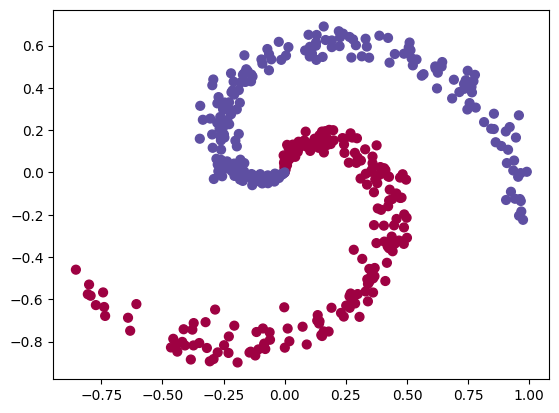

/home/robot/miniconda3/envs/ensia/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/robot/miniconda3/envs/ensia/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


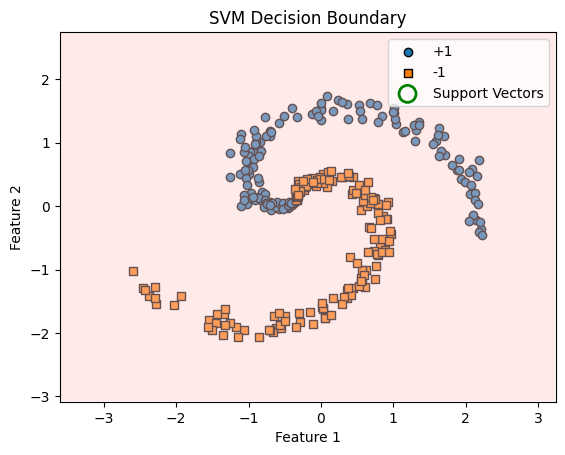

Accuracy: 0.54


In [22]:
X1_train, X1_test, y1_train, y1_test = load_non_linear_data(N=200)

cvxopt_model = CVXOPT_SVM(kernel="polynomial", degree=3, C=1) # TODO: Create CVXOPT_SVM and using a polynomial kernel
cvxopt_model.fit(X1_train, y1_train)
y_pred = cvxopt_model.predict(X1_test)
visualizeBoundary(X1_train, y1_train,cvxopt_model)
print(f"Accuracy: {sum(y1_test==y_pred)/y1_test.shape[0]}")

---
Re-run the dual SVM on your linear training set (X_train) and inspect the resulting decision boundary and accuracy.
* Soft-margin behavior arises when you choose a small C, which allows more slack and margin violations.

* Hard-margin behavior emerges as you increase C, penalizing violations more strongly and tightening the boundary.
Try several values of C to see how the classifier changes. Enjoy!

---

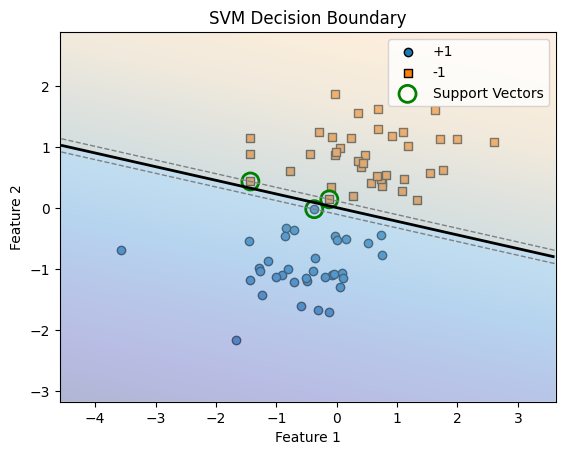

Accuracy: 1.0


In [23]:
cvxopt_model1 = CVXOPT_SVM(kernel="linear", C=100) # TODO: Create a cvxopt SVM object with C=100 and using a linear kernal
cvxopt_model1.fit(X_train, y_train)
y_pred1 = cvxopt_model1.predict(X_train)

visualizeBoundary(X_train, y_train, cvxopt_model1)
print(f"Accuracy: {sum(y_train==y_pred1)/y_train.shape[0]}")

---
# **PART III: Hyperparameter (Guided)**
---

In [24]:
!pip install ipywidgets
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
import ipywidgets as widgets
from ipywidgets import interact
from IPython.display import display, clear_output

# W,B Sliders


Support Vector Machines (SVM) make decisions based on a linear boundary (in the case of a linear kernel), which is defined by a weight vector `w` and a bias term `b`.

In this interactive section, you can explore how changing the values of the following parameters affects the decision boundary and margins:

- `w1` and `w2`: These are the components of the weight vector **w = [w1, w2]**.  
  - Changing `w1` or `w2` will **rotate or tilt** the decision boundary.  
  - A larger magnitude of the weight vector will make the boundary **steeper or flatter**, depending on the ratio between `w1` and `w2`.

- `b`: This is the **bias term**.  
  - Modifying `b` will **shift the decision boundary left or right**, without changing its orientation.

- `alpha`: This is a **scaling factor** applied to the weight vector.  
  - Increasing `alpha` makes the margins between the classes **narrower** (tighter), simulating a **harder margin**.  
  - Decreasing `alpha` makes the margins **wider**, simulating a **softer decision boundary**.

*Try adjusting the sliders to observe how the decision function and its contours change. This helps build intuition about how SVMs create and adjust classification boundaries.*


In [ ]:
delta = 0.1
x_grid, y_grid = np.meshgrid(
    np.arange(-4, 4, delta),
    np.arange(-4, 4, delta)
)

def update(w1=1.0, w2=1.0, b=0.0, alpha=1.0):
    clear_output(wait=True)

    fig, ax = plt.subplots(figsize=(8, 6))
    
    model_grid = alpha * (w1 * x_grid + w2 * y_grid) + b

    cs = ax.contour(x_grid, y_grid, model_grid, levels=[-2, -1, 0, 1, 2])
    ax.clabel(cs)

    ax.set_aspect('equal')
    ax.set_title(f'Contour Plot: {alpha}*({w1}*x + {w2}*y) + {b}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.grid(True)
    display(fig)
    plt.close(fig)

# Create interactive widgets
interact(
    update,
    w1=widgets.FloatSlider(min=-10, max=10, step=0.1, value=1),
    w2=widgets.FloatSlider(min=-10, max=10, step=0.1, value=1),
    b=widgets.FloatSlider(min=-10, max=10, step=0.1, value=0),
    alpha=widgets.FloatSlider(min=0.1, max=5, step=0.1, value=1)
)

interactive(children=(FloatSlider(value=1.0, description='w1', max=10.0, min=-10.0), FloatSlider(value=1.0, de…

<function __main__.update(w1=1.0, w2=1.0, b=0.0, alpha=1.0)>

# C Slider


This interactive plot helps you visualize how two key hyperparameters of an SVM classifier affect the decision boundary:

- **C (Regularization Parameter):**
  - Controls the **trade-off between maximizing the margin and minimizing classification errors**.
  - A **small `C`** makes the margin wider but allows more misclassifications (soft margin).
  - A **large `C`** tries to classify all training examples correctly, resulting in a narrower margin and potentially overfitting.

- **Kernel Type:**
  - **Linear kernel**: Attempts to separate the data with a straight line (good for linearly separable data).
  - **RBF (Radial Basis Function) kernel**: Allows for **non-linear separation**, useful when data is not linearly separable.

 Try switching between kernels and adjusting the value of `C` to see how the decision boundary and margins change.

In [ ]:
# Close all existing figures
plt.close('all')

# Define the training data
x_train = np.array([
    [1,1],
    [2,1],
    [3,3],
    [4,1],
    [2,2],
    [2.5,1.5], #really good seperable example
])
y_train = np.array([0,0,1,1,1,0])

# Create grid for visualization
delta = 0.1
x_grid, y_grid = np.meshgrid(np.arange(0, 4, delta), np.arange(0, 4, delta))
grid_dataset = np.hstack([x_grid.reshape(-1,1), y_grid.reshape(-1,1)])

def update(cur_c=1.0, kernel_toggle=False):
    # Create a new figure each time
    plt.figure(figsize=(8, 6))

    # Select kernel based on toggle
    cur_kernel = 'rbf' if kernel_toggle else 'linear'

    # Fit SVM model
    fitted_model = SVC(kernel=cur_kernel, C=cur_c).fit(x_train, y_train)
    out = fitted_model.decision_function(grid_dataset)

    # Plot data points
    plt.scatter(x_train[:,0], x_train[:,1], c=y_train, cmap=plt.cm.Paired,
               edgecolors='k', s=100)

    # Create decision boundary contour
    model_grid = out.reshape(x_grid.shape)
    cs = plt.contour(x_grid, y_grid, model_grid, levels=[-1, 0, 1], colors=['#808080', '#000000', '#808080'],
                    linestyles=['--', '-', '--'])
    plt.clabel(cs, inline=1, fontsize=10)

    # Add plot labels and title
    plt.title(f'SVM with {cur_kernel} kernel, C={cur_c:.3f}')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.xlim(0, 4)
    plt.ylim(0, 4)
    plt.grid(True, alpha=0.3)

    # Show the plot - this is crucial for Colab
    plt.tight_layout()
    plt.show()

# Create interactive widgets
interact(update,
         cur_c=widgets.FloatLogSlider(min=-3, max=2, value=0, description='C:',
                                   base=10, step=0.1),
         kernel_toggle=widgets.ToggleButton(value=False, description="RBF Kernel"));

interactive(children=(FloatLogSlider(value=0.001, description='C:', max=2.0, min=-3.0), ToggleButton(value=Fal…

# Gamma Slider


In this interactive example, we're using an **SVM with a Radial Basis Function (RBF) kernel** to handle a **non-linearly separable dataset**.

Two important hyperparameters control the shape and flexibility of the decision boundary:

- **C (Regularization parameter):**
  - As in the previous example, a small `C` creates a wider margin but allows some misclassifications.
  - A large `C` forces the model to fit the training data more strictly, potentially overfitting.

- **gamma (Kernel coefficient for RBF):**
  - Controls the **influence of a single training point**.
  - A **low gamma** means far-away points have more influence → smoother decision boundary.
  - A **high gamma** leads to a more complex decision boundary that tightly wraps around training points → can overfit.

 **Tip:** Try setting `C` very high and gradually increasing `gamma`. Watch how the decision boundary becomes wiggly and overly sensitive to each data point. Then try a low `gamma` — what changes?

This setup helps you develop an intuition for how kernel methods and hyperparameter tuning affect model flexibility and generalization.


In [27]:
plt.close('all')

# Dataset with non-separable example
x_train = np.array([
    [1,1],
    [2,1],
    [3,3],
    [4,1],
    [2,2],
    [2.5,2], # non-separable example
])
y_train = np.array([0,0,1,1,1,0])

# Create grid for visualization
delta = 0.05
x_grid, y_grid = np.meshgrid(np.arange(0, 4, delta), np.arange(0, 4, delta))
grid_dataset = np.hstack([x_grid.reshape(-1,1), y_grid.reshape(-1,1)])

def update(C=1.0, gamma=1.0):
    # Create a new figure each time for Colab compatibility
    plt.figure(figsize=(8, 6))

    # Fit SVM model with RBF kernel
    fitted_model = SVC(kernel='rbf', C=C, gamma=gamma).fit(x_train, y_train)
    out = fitted_model.decision_function(grid_dataset)

    # Plot data points
    plt.scatter(x_train[:,0], x_train[:,1], c=y_train, cmap=plt.cm.Paired,
               edgecolors='k', s=100)

    # Create decision boundary contour
    model_grid = out.reshape(x_grid.shape)
    cs = plt.contour(x_grid, y_grid, model_grid, levels=[-1, 0, 1],
                    colors=['#808080', '#000000', '#808080'],
                    linestyles=['--', '-', '--'])
    plt.clabel(cs, inline=1, fontsize=10)

    # Add plot labels and title
    plt.title(f'SVM with RBF kernel, C={C:.3f}, gamma={gamma:.3f}')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.xlim(0, 4)
    plt.ylim(0, 4)
    plt.grid(True, alpha=0.3)

    # Show the plot
    plt.tight_layout()
    plt.show()

# Create interactive widgets
interact(update,
         C=widgets.FloatLogSlider(min=-3, max=2, value=0, description='C:',
                                base=10, step=0.1),
         gamma=widgets.FloatLogSlider(min=-3, max=2, value=0, description='gamma:',
                                    base=10, step=0.1));

interactive(children=(FloatLogSlider(value=0.001, description='C:', max=2.0, min=-3.0), FloatLogSlider(value=0…